## Relay ramp model
- This is a synthetic model to mimic relay ramp
- The fault area are defined as ellipsoids

In [1]:
import geoinr_faults as grf
import numpy as np

Define the model conditions

In [2]:
geomodel = grf.create_geomodel(
    project_name='Relay_ramp',
    extent=[0, 10000, 0, 8000, 0, 5000],
    resolution=[400, 100, 300],
    path_to_surface_points='input_data/Relay_ramp/Relay_ramp_obs_points.csv',
    path_to_orientations=None,
)

In [3]:
geomodel

GeoModel('Relay_ramp', extent=[0, 10000, 0, 8000, 0, 5000], resolution=[400, 100, 300], stratis=0, horizons=[], faults=0)

Add stratigraphy column

In [4]:
geomodel = grf.add_stratis(geomodel, strati_configs=[
    grf.StratiConfig(name="strati_A", formations=['4', '3', '2', '1']),
    ])

In [5]:
geomodel

GeoModel('Relay_ramp', extent=[0, 10000, 0, 8000, 0, 5000], resolution=[400, 100, 300], stratis=1, horizons=[4], faults=0)

In [6]:
#grf.plot_input_data(geomodel, notebook=True, legend_size=(0.22, 0.22))

Add faults, here the fault trunction rules are used, if `truncation` is true, need to define the truncting fault
- using custom ellipsoidal center to better mimic the fault zone

In [7]:
geomodel = grf.add_faults(geomodel, fault_configs=[
    grf.FaultConfig(name='f1', lx=5000, ly=6000, lz=15000, X0=1000, Y0=0, Z0=5000, theta=np.deg2rad(90), phi=np.deg2rad(60),
                   dmax=1, lam=0.5, Normal_fault=False),
    grf.FaultConfig(name='f2', lx=2300, ly=4000, lz=10000, X0=4250, Y0=3500, Z0=5000, theta=np.deg2rad(90), phi=np.deg2rad(60),
                   dmax=1, lam=0.5, Normal_fault=False),
    grf.FaultConfig(name='f3', lx=2300, ly=4500, lz=10000, X0=6000, Y0=5000, Z0=5000, theta=np.deg2rad(90), phi=np.deg2rad(60),
                   dmax=1, lam=0.5, Normal_fault=False),
    grf.FaultConfig(name='f4', lx=4000, ly=4000, lz=10000, X0=8500, Y0=8000, Z0=5000, theta=np.deg2rad(90), phi=np.deg2rad(60),
                   dmax=1, lam=0.5, Normal_fault=False),
])

In [8]:
geomodel

GeoModel('Relay_ramp', extent=[0, 10000, 0, 8000, 0, 5000], resolution=[400, 100, 300], stratis=1, horizons=[4], faults=4)

Visualization of fault feature fields

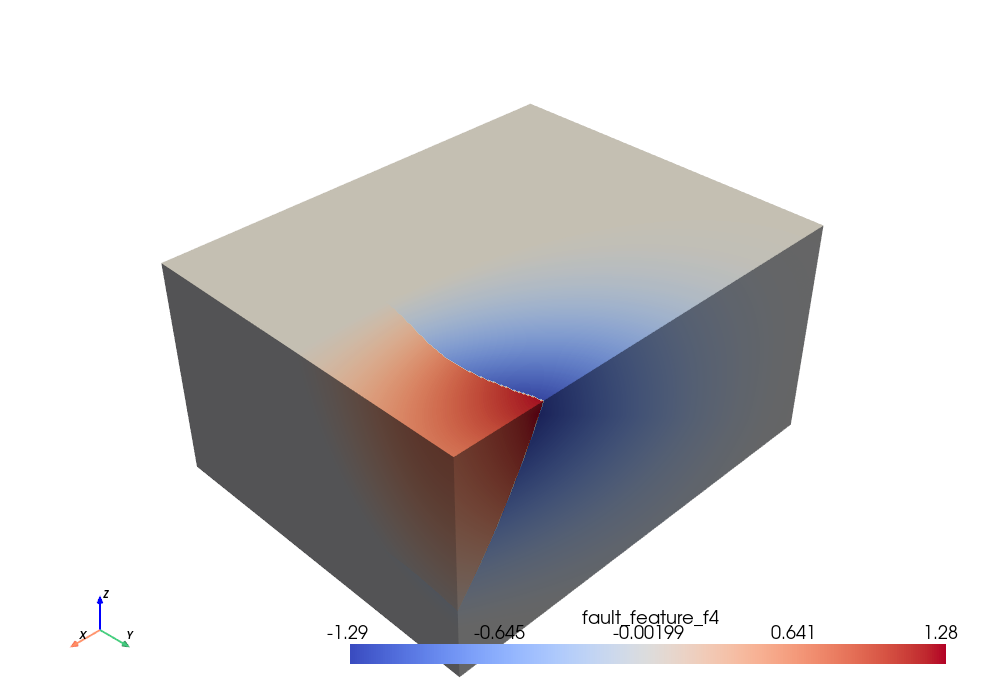

In [9]:
grf.plot_fault_features(geomodel, fault_name='f4', cmap='coolwarm', notebook=True, camera_position=None)

Visualizing fault surfaces

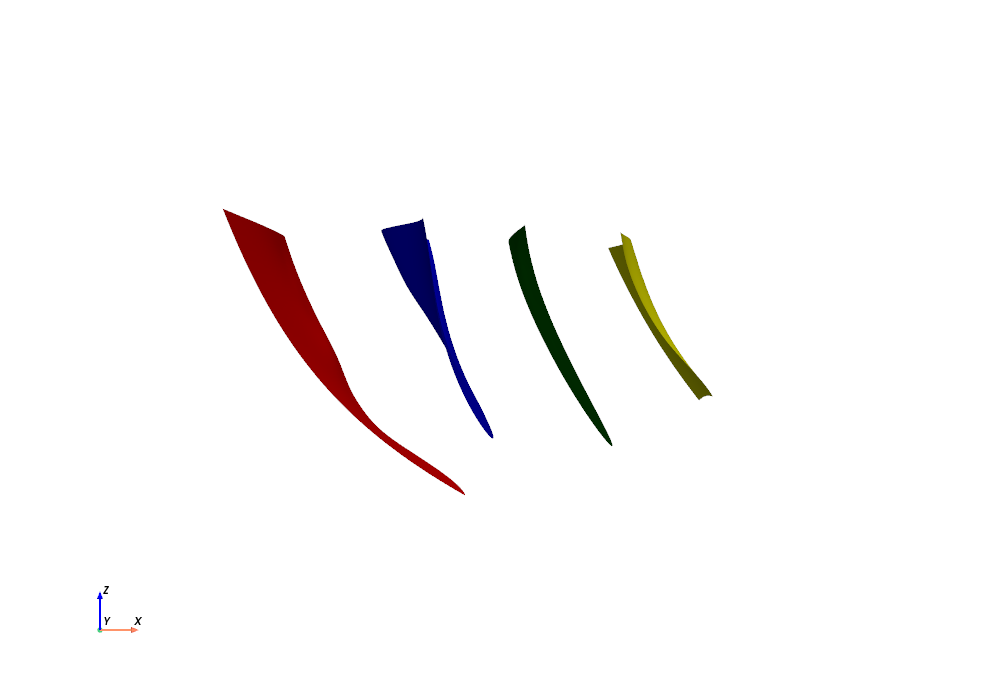

In [10]:
grf.plot_fault_meshes(geomodel, notebook=True)

Compute model

In [11]:
results = grf.compute_model(
    geomodel,
    nn_model='mlp',          # 'mlp' | 'siren' | 'resnet'  or custom class
    hidden_dim=256,
    n_layers=3,
    activation='softplus',   # 'softplus' | 'relu' | 'tanh' | 'sine' | ...
    softplus_beta=30,
    epochs=2000,
    lr=1e-3,
    seed=202507,
)

Epoch [500/2000]  Loss: 0.0131  Var: 0.0000  On: 0.0131  Above: 0.0000  Below: 0.0000  Orie: 0.0000  Best: 0.0091
Epoch [1000/2000]  Loss: 0.0088  Var: 0.0000  On: 0.0088  Above: 0.0000  Below: 0.0000  Orie: 0.0000  Best: 0.0044
Epoch [1500/2000]  Loss: 0.0080  Var: 0.0000  On: 0.0080  Above: 0.0000  Below: 0.0000  Orie: 0.0000  Best: 0.0036
Epoch [2000/2000]  Loss: 0.0118  Var: 0.0001  On: 0.0117  Above: 0.0000  Below: 0.0000  Orie: 0.0000  Best: 0.0032

Training finished in 13.3 s  |  Best loss: 0.0032
Inference completed in 0.2740 s


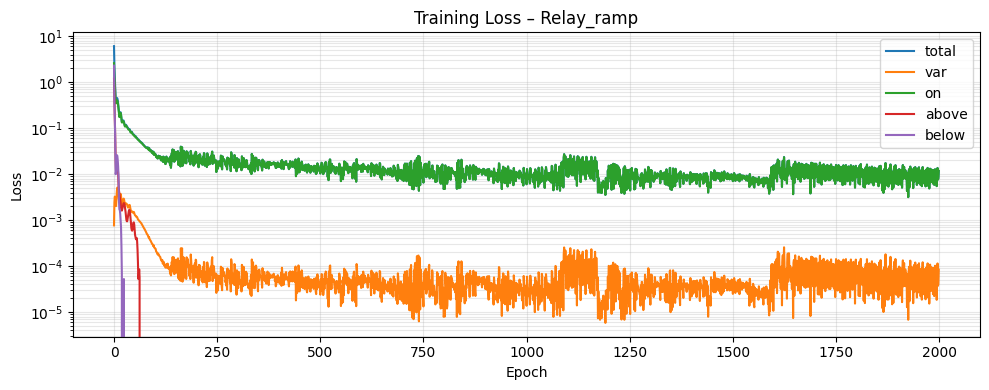

In [12]:
grf.plot_loss(results)

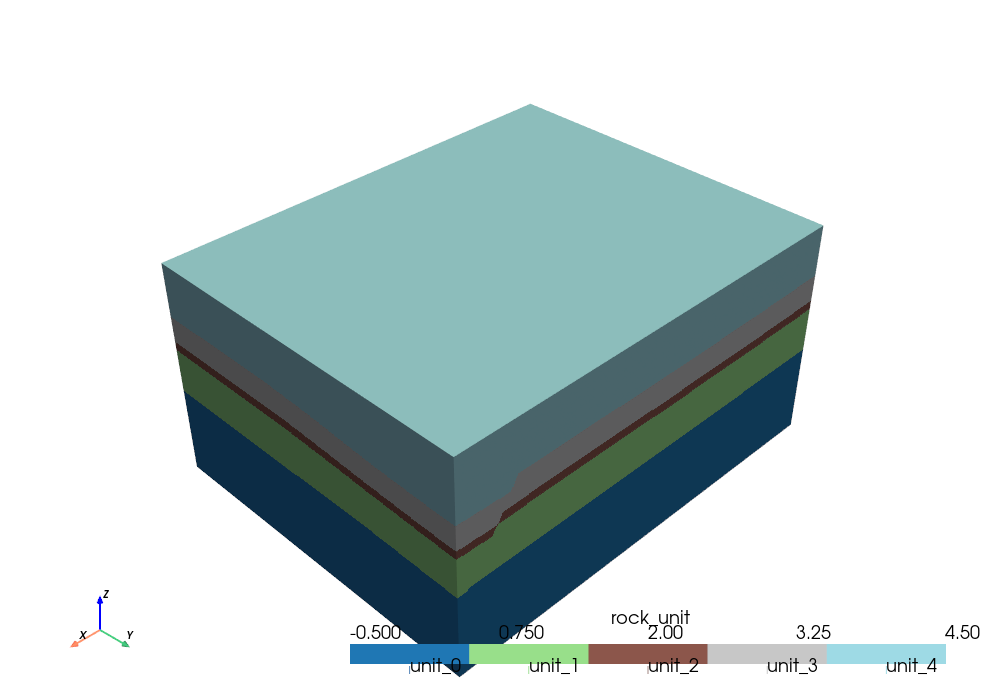

In [13]:
grf.plot_model(results, notebook=True, show_scalar_field=False, show_fault_points=False, show_interface_points=False, show_rock_unit=True)

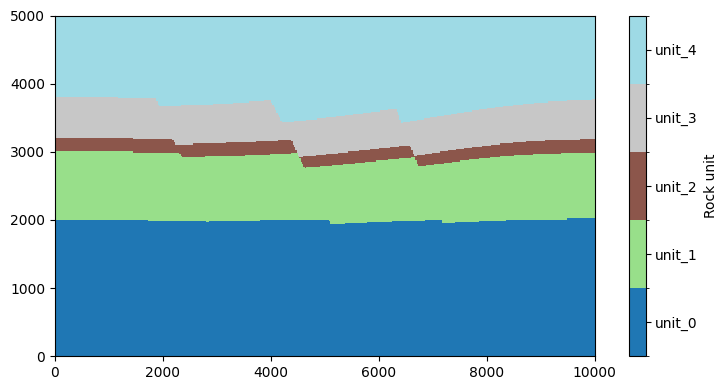

In [14]:
grf.plot_section_rock_unit(results, axis='y',figsize=(7.5, 4))